In [1]:
import networkx as nx


In [ ]:

SURFACE_AREA_VOX = 80

G = nx.Graph()
with open('c40k_pre_post_weights.csv', 'r') as f:
    for line in f.readlines():
        if line.startswith('#'):
            continue
        src, dst, weight = line.strip().split(',')
        weight = float(weight)
        u, v = sorted([src, dst])
        if not G.has_edge(u, v):
            G.add_edge(u, v, weight=weight * SURFACE_AREA_VOX)
        else:
            G[u][v]['weight'] += weight * SURFACE_AREA_VOX
print(len(G.nodes()), len(G.edges()))
with open('c40k_weighted.csv', 'w') as f:
    for u, v in G.edges():
        f.write(f"{u},{v},{int(G[u][v]['weight'])}\n")

In [9]:
len(g.nodes()), len(g.edges())

(244187, 1138603)

In [2]:
G = nx.Graph()
with open('c40k_weighted.csv', 'r') as f:
    for line in f:
        u, v, weight = line.strip().split(',')
        G.add_edge(u, v, weight=int(weight))

In [3]:
len(G.nodes()), len(G.edges())

(244187, 570849)

In [ ]:
# average degree
avg_degree = sum(dict(G.degree()).values()) / len(G.nodes())

In [9]:
# median degree
median_degree = sorted(dict(G.degree()).values())[len(G.nodes()) // 2]
median_degree

3

In [10]:
!uv add matplotlib

Resolved 136 packages in 637ms                                       
⠙ Preparing packages... (0/6)                                                   
⠙ Preparing packages... (0/6)----     0 B/254.64 kB                     
⠙ Preparing packages... (0/6)---- 2.76 kB/254.64 kB                     
⠙ Preparing packages... (0/6)---- 6.89 kB/254.64 kB                     
⠙ Preparing packages... (0/6)---- 11.02 kB/254.64 kB                    
⠙ Preparing packages... (0/6)---- 12.40 kB/254.64 kB                    
⠙ Preparing packages... (0/6)---- 15.27 kB/254.64 kB                    
contourpy  ------------------------------ 15.27 kB/254.64 kB
⠙ Preparing packages... (0/6)----     0 B/2.76 MB                       
contourpy  ------------------------------ 15.27 kB/254.64 kB
⠙ Preparing packages... (0/6)---- 2.76 kB/2.76 MB                       
contourpy  ------------------------------ 15.27 kB/254.64 kB
⠙ Preparing packages... (0/6)---- 6.89 kB/2.76 MB                       
contourpy

Text(0, 0.5, 'Frequency')

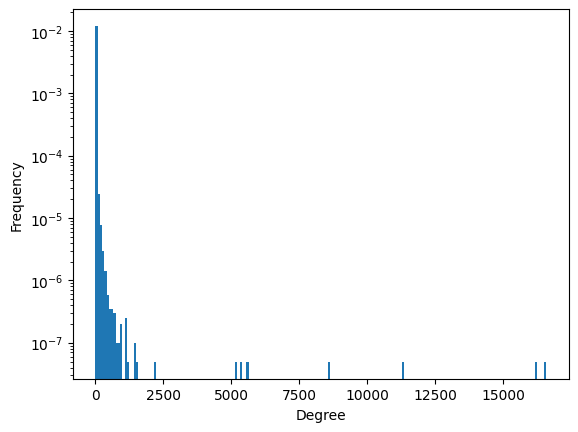

In [13]:
# hist of degree distribution
import matplotlib.pyplot as plt
import numpy as np

degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
plt.hist(degree_sequence, bins=200, density=True)
plt.yscale('log')
plt.xlabel('Degree')
plt.ylabel('Frequency')

In [7]:
degree_sequence

NameError: name 'degree_sequence' is not defined